In [1]:
# external lib imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

In [2]:
# internal lib import
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from core import NeuralNetwork


In [ ]:
# Load the dataset
df = pd.read_csv("../data/datasetml_2026.csv")

In [4]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [ ]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status'].values
y = np.where(y == "Placed", 1, 0) 

# Preprocess Categorical and Numerical Columns
categorical_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
numerical_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Reshape y for the Neural Network to (batch_size, 1)
# If using Binary Cross Entropy:
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (8000, 23)
y_train shape: (8000, 1)


=== STARTING WIDTH EXPERIMENTS ===

Training Width: Narrow (16 neurons)

Training Width: Medium (64 neurons)

Training Width: Wide (128 neurons)

=== STARTING DEPTH EXPERIMENTS ===

Training Depth: Shallow (1 Hidden)

Training Depth: Medium (3 Hidden)

Training Depth: Deep (5 Hidden)

=== FINAL PREDICTION COMPARISON (ACCURACY ON VALIDATION SET) ===

--- Width Variations ---
Narrow (16 neurons): 65.70%
Medium (64 neurons): 66.75%
Wide (128 neurons): 74.60%

--- Depth Variations ---
Shallow (1 Hidden): 72.30%
Medium (3 Hidden): 67.85%
Deep (5 Hidden): 61.25%


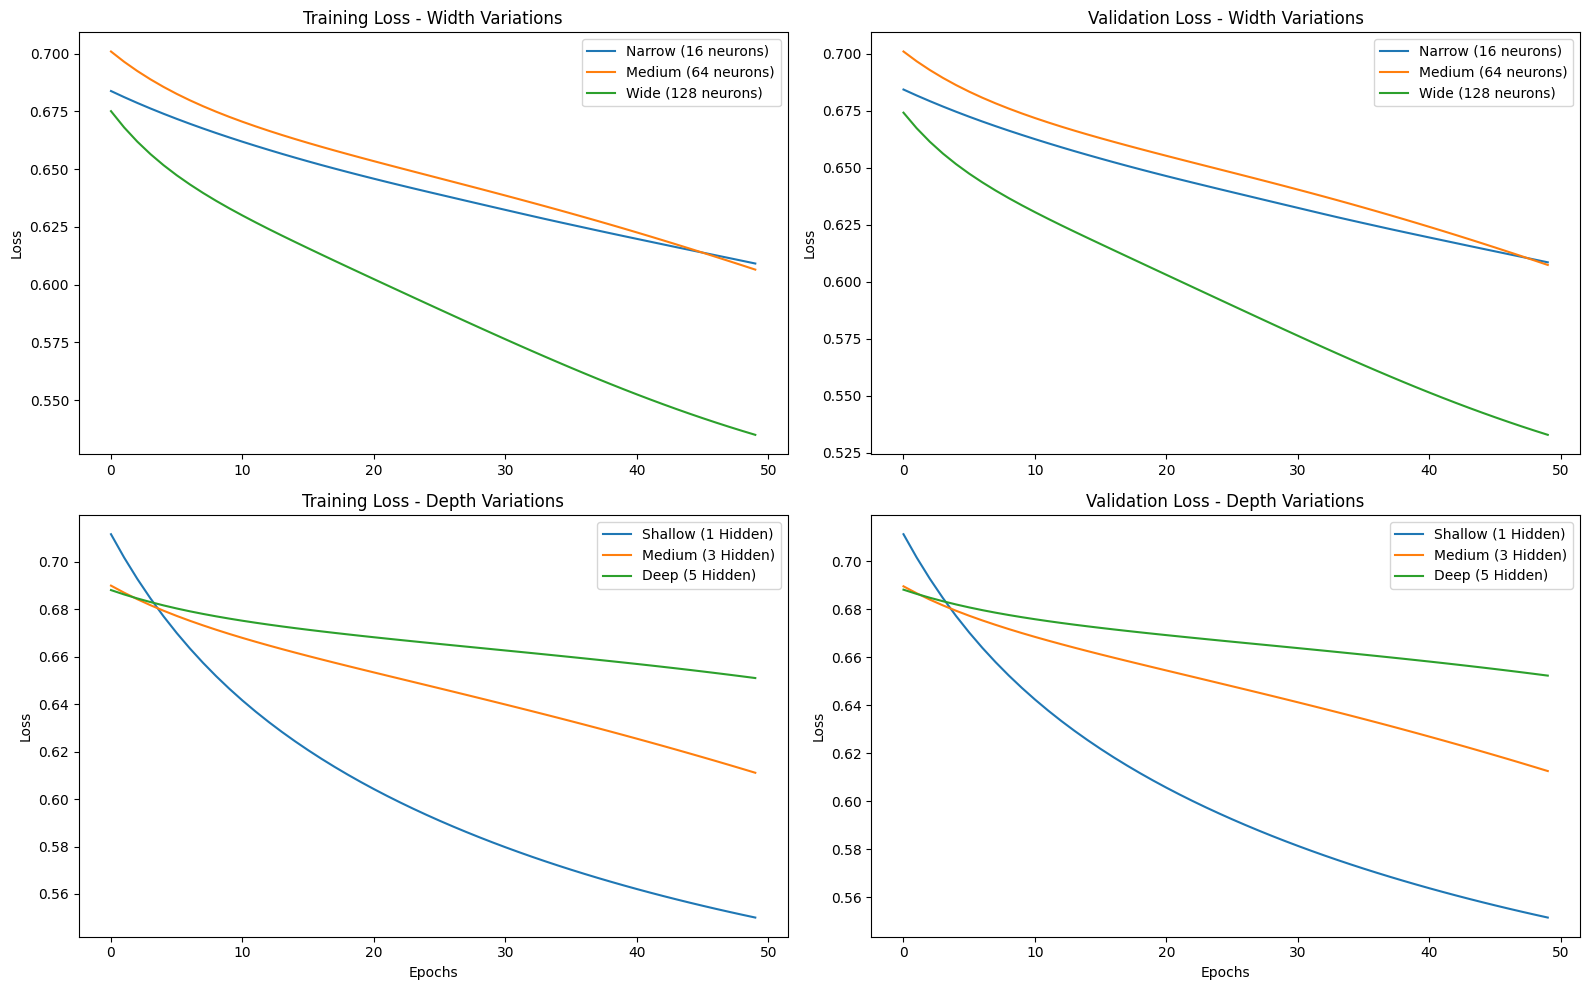

In [6]:
# --- EXPERIMENT 1: DEPTH vs. WIDTH ---
input_dim = X_train.shape[1]
output_dim = 1 # Binary Classification

# 1. Define Configurations
# Width Variations (Fixed Depth: 3 Hidden Layers)
width_configs = {
    "Narrow (16 neurons)": [input_dim, 16, 16, 16, output_dim],
    "Medium (64 neurons)": [input_dim, 64, 64, 64, output_dim],
    "Wide (128 neurons)":  [input_dim, 128, 128, 128, output_dim]
}

# Depth Variations (Fixed Width: 32 neurons per Hidden Layer)
depth_configs = {
    "Shallow (1 Hidden)": [input_dim, 32, output_dim],
    "Medium (3 Hidden)":  [input_dim, 32, 32, 32, output_dim],
    "Deep (5 Hidden)":    [input_dim, 32, 32, 32, 32, 32, output_dim]
}

# Dictionaries to store results
histories_width = {}
models_width = {}
histories_depth = {}
models_depth = {}

# Helper function to train and store models
def train_variations(configs, histories_dict, models_dict, exp_name):
    for name, layers in configs.items():
        print(f"\nTraining {exp_name}: {name}")
        
        # All hidden layers use ReLU, output uses Sigmoid
        acts = ["relu"] * (len(layers) - 2) + ["sigmoid"]
        
        model = NeuralNetwork(
            layer_sizes=layers,
            activations=acts,
            loss="bce" 
        )
        
        history = model.fit(
            X_train=X_train, y_train=y_train, 
            val_data=(X_val, y_val),
            epochs=50, batch_size=32, learning_rate=0.01, verbose=0 # Set verbose=0 for cleaner output
        )
        
        histories_dict[name] = history
        models_dict[name] = model

# Train both sets
print("=== STARTING WIDTH EXPERIMENTS ===")
train_variations(width_configs, histories_width, models_width, "Width")

print("\n=== STARTING DEPTH EXPERIMENTS ===")
train_variations(depth_configs, histories_depth, models_depth, "Depth")

# 2. Compare Final Predictions (Accuracy) 
print("\n=== FINAL PREDICTION COMPARISON (ACCURACY ON VALIDATION SET) ===")

def evaluate_models(models_dict):
    for name, model in models_dict.items():
        # Predict probabilities and convert to 0 or 1
        y_pred_prob = model.predict(X_val)
        y_pred_class = (y_pred_prob > 0.5).astype(int)
        acc = accuracy_score(y_val, y_pred_class)
        print(f"{name}: {acc * 100:.2f}%")

print("\n--- Width Variations ---")
evaluate_models(models_width)

print("\n--- Depth Variations ---")
evaluate_models(models_depth)

# 3. Plotting Training and Validation Loss 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Width Plots
for name, hist in histories_width.items():
    axes[0, 0].plot(hist['train_loss'], label=name)
    axes[0, 1].plot(hist['val_loss'], label=name)

axes[0, 0].set_title('Training Loss - Width Variations')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].set_title('Validation Loss - Width Variations')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Depth Plots
for name, hist in histories_depth.items():
    axes[1, 0].plot(hist['train_loss'], label=name)
    axes[1, 1].plot(hist['val_loss'], label=name)

axes[1, 0].set_title('Training Loss - Depth Variations')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

axes[1, 1].set_title('Validation Loss - Depth Variations')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


--- Training with LINEAR in Hidden Layer 1 ---
Distributions for LINEAR:


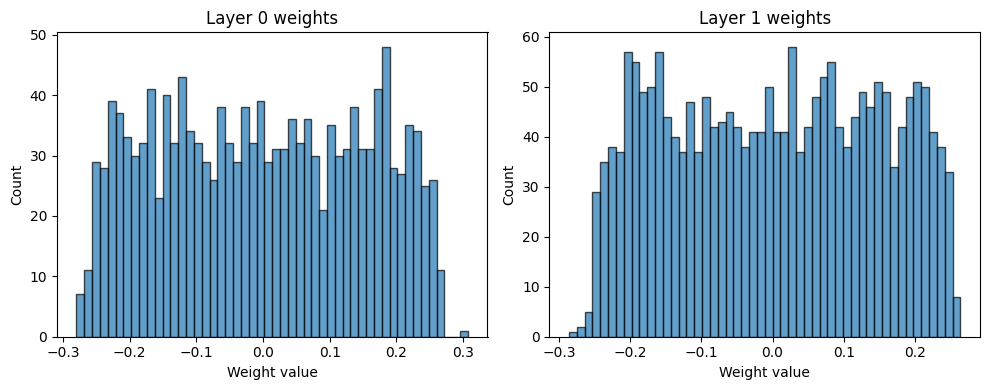

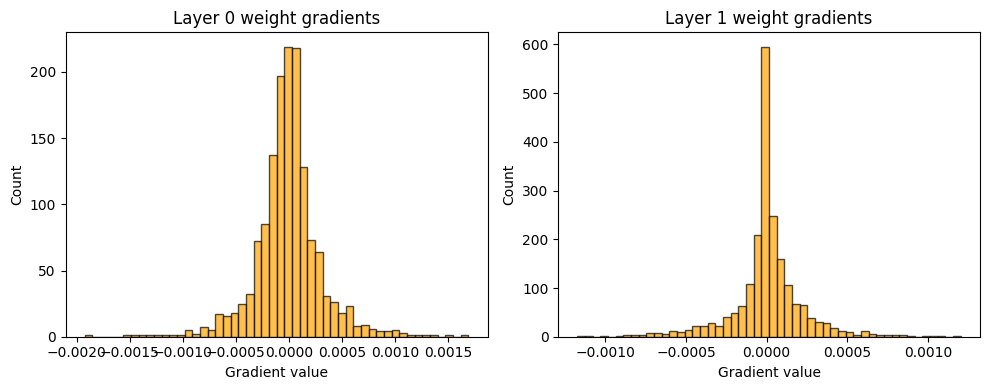


--- Training with RELU in Hidden Layer 1 ---
Distributions for RELU:


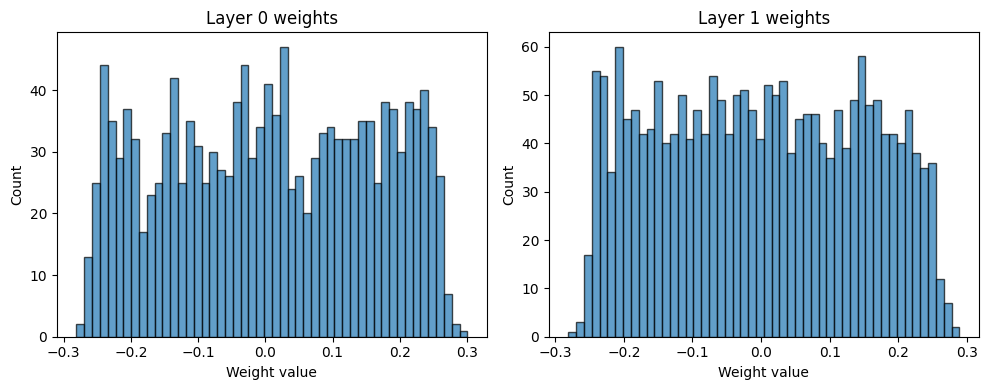

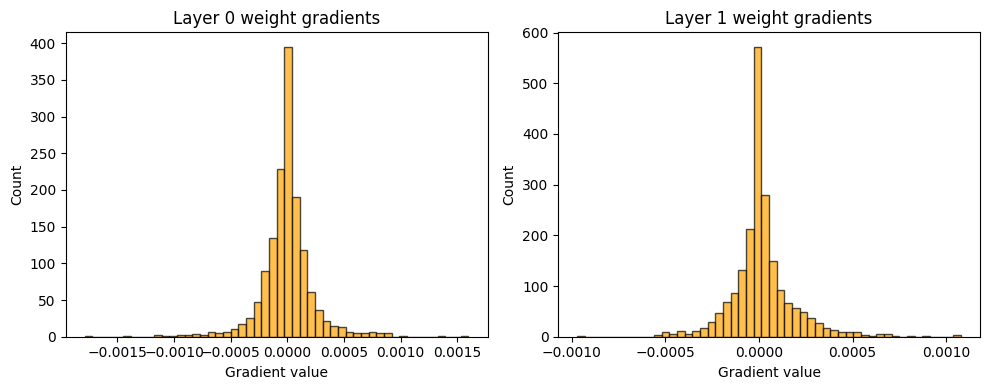


--- Training with SIGMOID in Hidden Layer 1 ---
Distributions for SIGMOID:


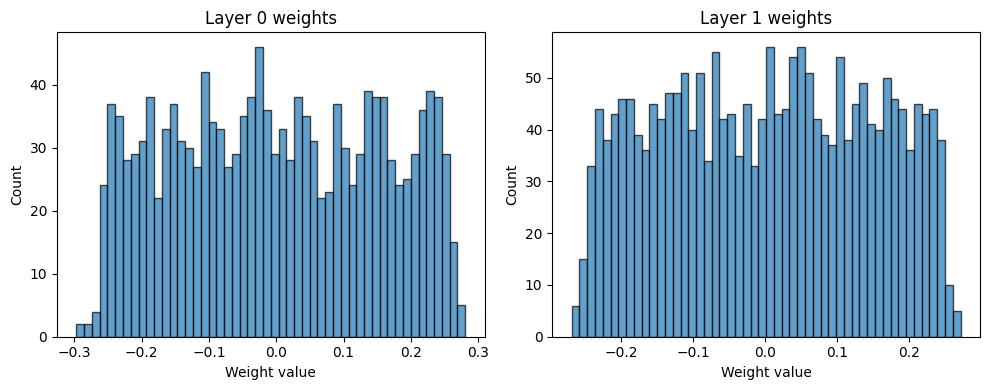

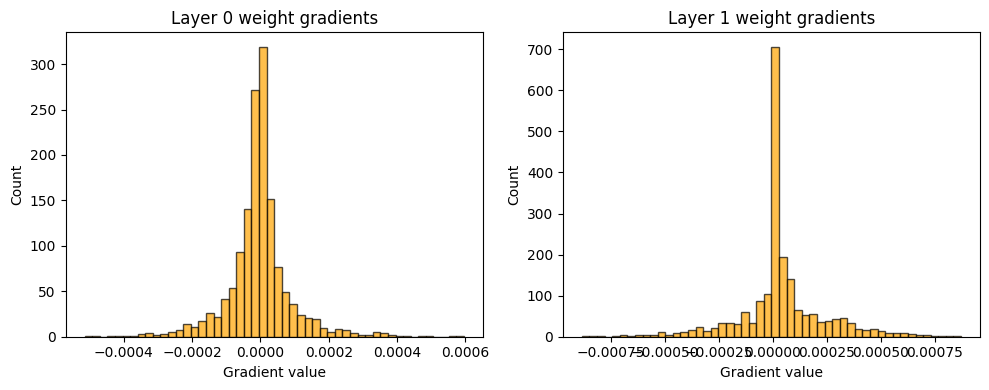


--- Training with TANH in Hidden Layer 1 ---
Distributions for TANH:


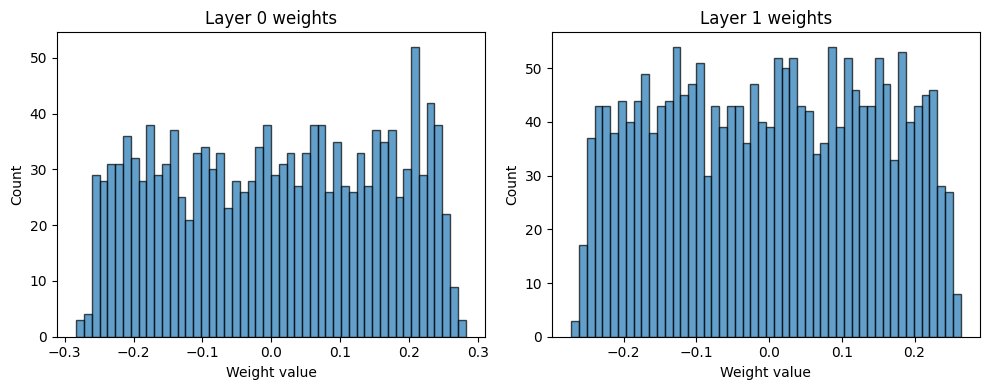

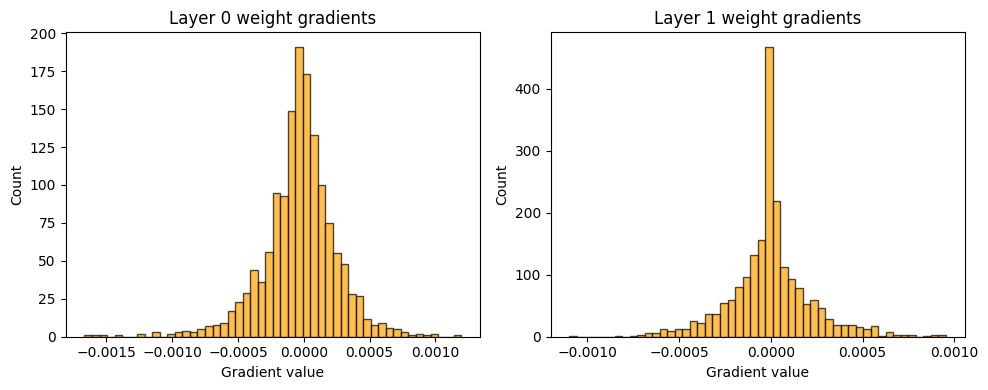

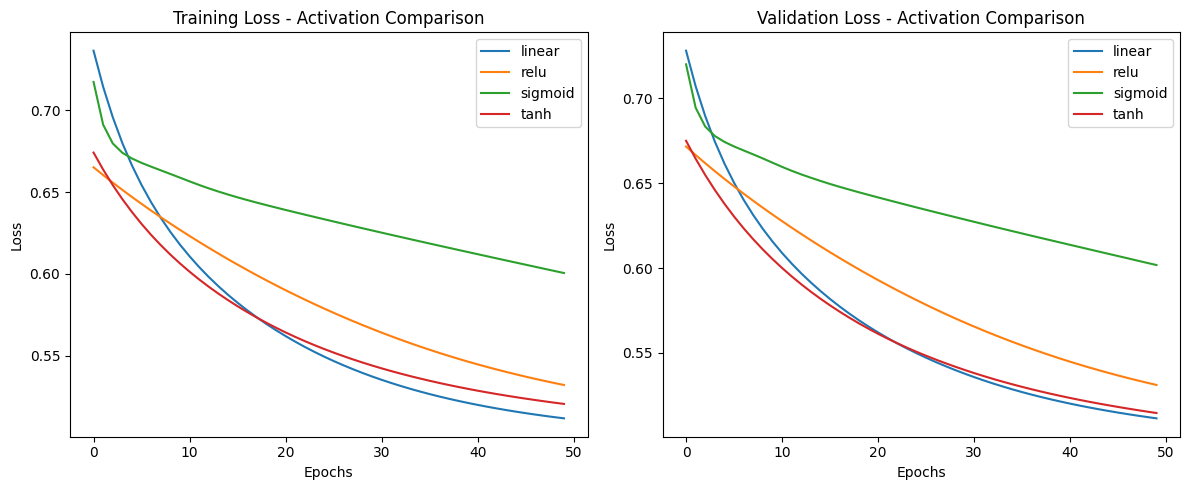

In [ ]:
# --- EXPERIMENT: ACTIVATION FUNCTIONS ---

# Base Architecture: Input -> Hidden (Test Layer) -> Hidden -> Output
input_dim = X_train.shape[1]
base_layers = [input_dim, 64, 32, 1]
activations_to_test = ["linear", "relu", "sigmoid", "tanh"]

histories_act = {}
models_act = {}

for act in activations_to_test:
    print(f"\n--- Training with {act.upper()} in Hidden Layer 1 ---")
    
    # We vary the first hidden layer, keep the second as relu, and output as sigmoid
    acts = [act, "relu", "sigmoid"]
    
    model = NeuralNetwork(
        layer_sizes=base_layers,
        activations=acts,
        loss="bce"
    )
    
    history = model.fit(
        X_train=X_train, y_train=y_train, 
        val_data=(X_val, y_val),
        epochs=50, batch_size=32, learning_rate=0.01, verbose=0 # Set verbose=0 to reduce spam
    )
    
    histories_act[act] = history
    models_act[act] = model
    
    # Plotting Distributions for this specific model
    print(f"Distributions for {act.upper()}:")
    model.plot_weight_distribution(layers=[0, 1])
    model.plot_gradient_distribution(layers=[0, 1])

# Plotting Loss Comparisons
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for act, hist in histories_act.items():
    plt.plot(hist['train_loss'], label=act)
plt.title('Training Loss - Activation Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for act, hist in histories_act.items():
    plt.plot(hist['val_loss'], label=act)
plt.title('Validation Loss - Activation Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


--- Training with Learning Rate: 0.1 ---


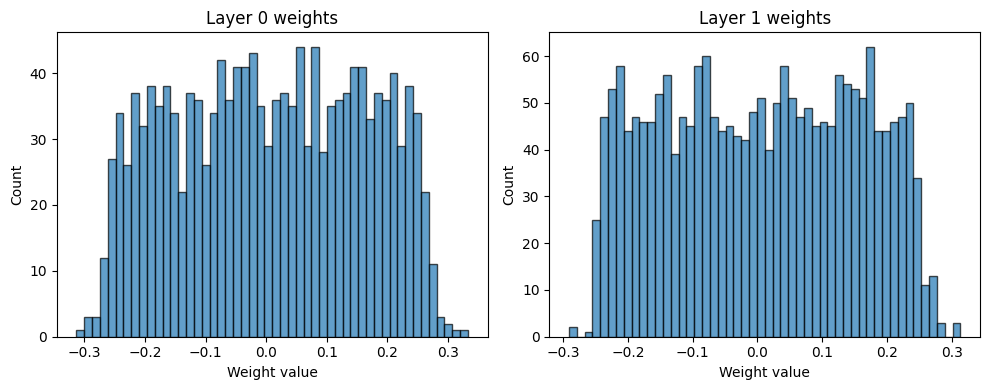

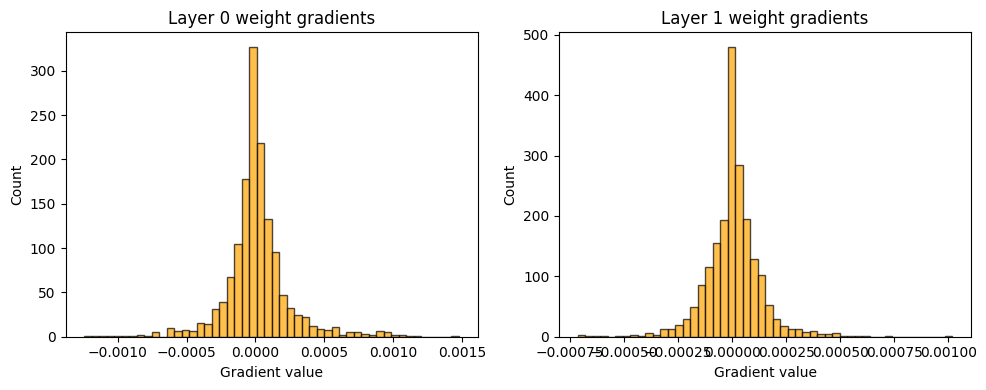


--- Training with Learning Rate: 0.01 ---


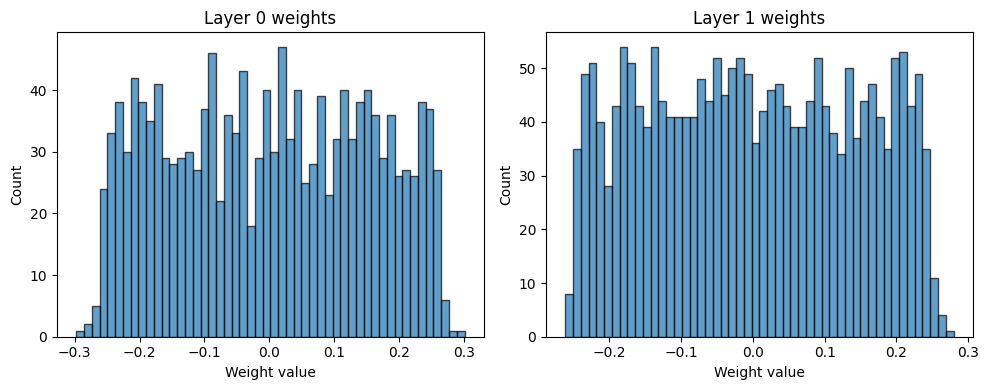

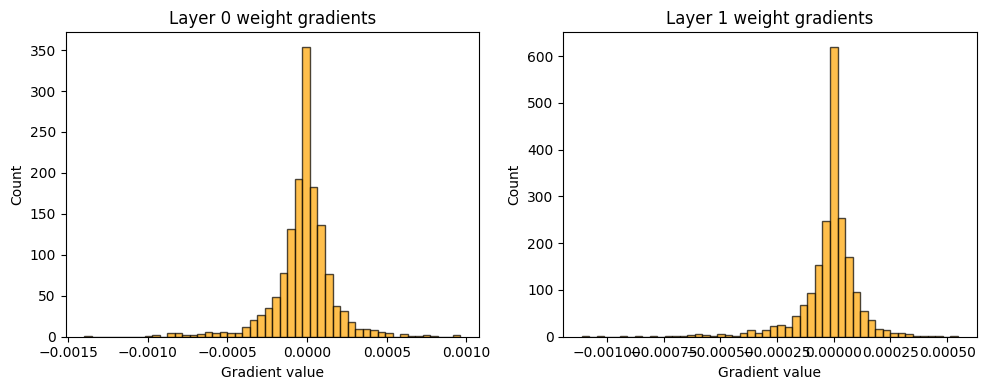


--- Training with Learning Rate: 0.001 ---


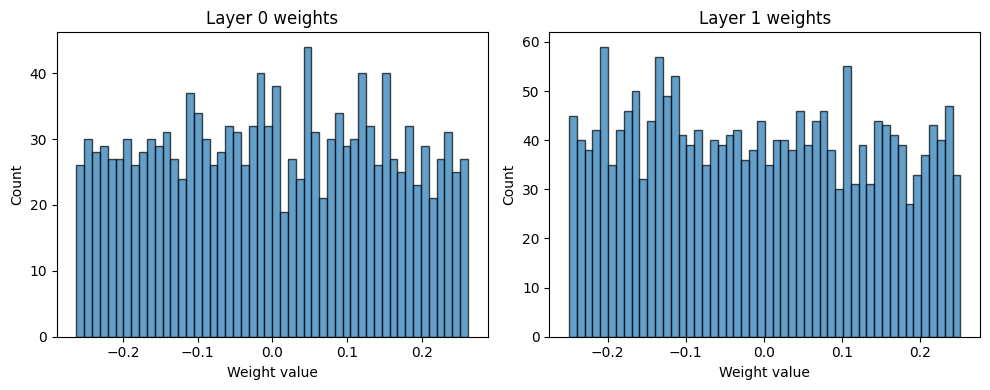

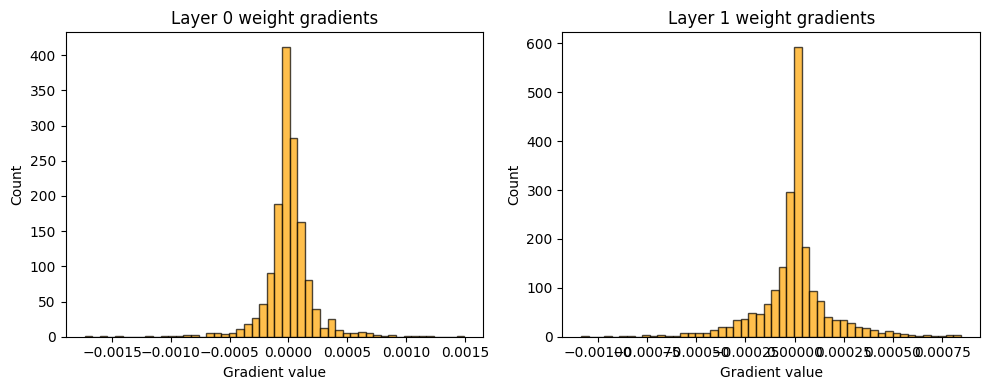

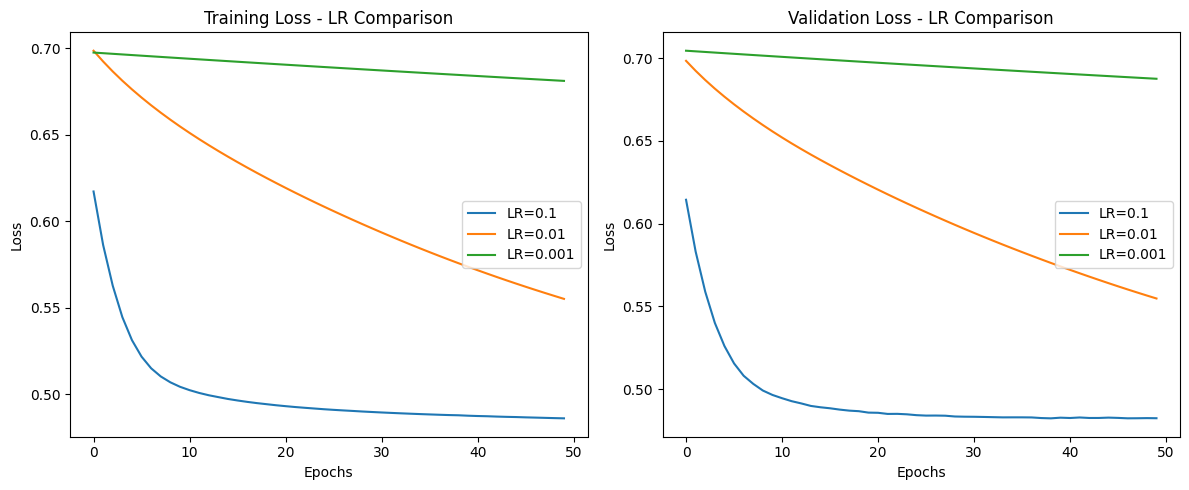

In [8]:
# --- EXPERIMENT: LEARNING RATE ---

fixed_layers = [input_dim, 64, 32, 1]
fixed_acts = ["relu", "relu", "sigmoid"]
learning_rates = [0.1, 0.01, 0.001]

histories_lr = {}
models_lr = {}

for lr in learning_rates:
    print(f"\n--- Training with Learning Rate: {lr} ---")
    
    model = NeuralNetwork(
        layer_sizes=fixed_layers,
        activations=fixed_acts,
        loss="bce"
    )
    
    history = model.fit(
        X_train=X_train, y_train=y_train, 
        val_data=(X_val, y_val),
        epochs=50, batch_size=32, learning_rate=lr, verbose=0
    )
    
    histories_lr[f"LR={lr}"] = history
    models_lr[f"LR={lr}"] = model
    
    # Plot distributions [cite: 111]
    model.plot_weight_distribution(layers=[0, 1])
    model.plot_gradient_distribution(layers=[0, 1])

# Plotting Loss Comparisons
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for lr_name, hist in histories_lr.items():
    plt.plot(hist['train_loss'], label=lr_name)
plt.title('Training Loss - LR Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for lr_name, hist in histories_lr.items():
    plt.plot(hist['val_loss'], label=lr_name)
plt.title('Validation Loss - LR Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


--- Training with Regularization: NONE ---


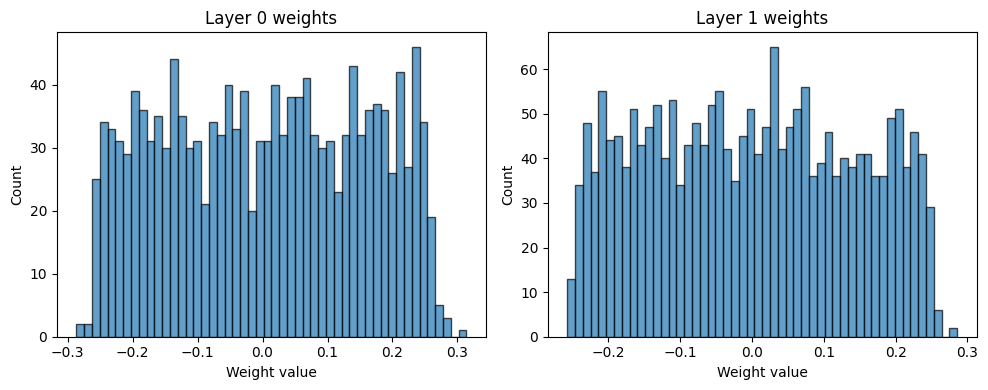

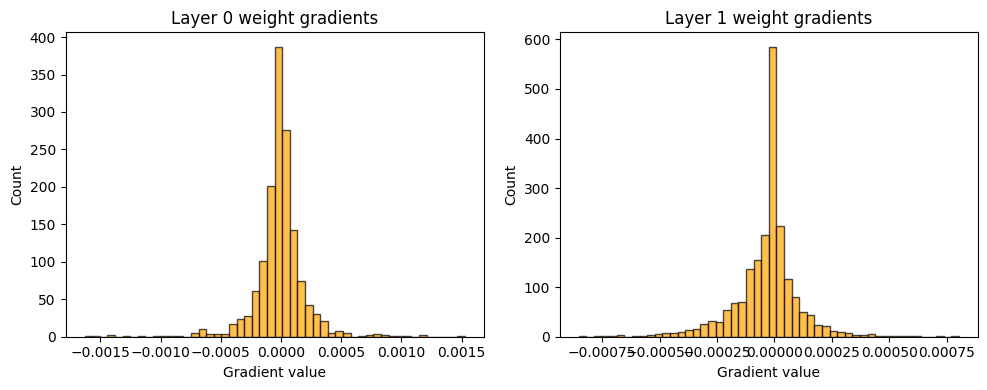


--- Training with Regularization: L1 ---


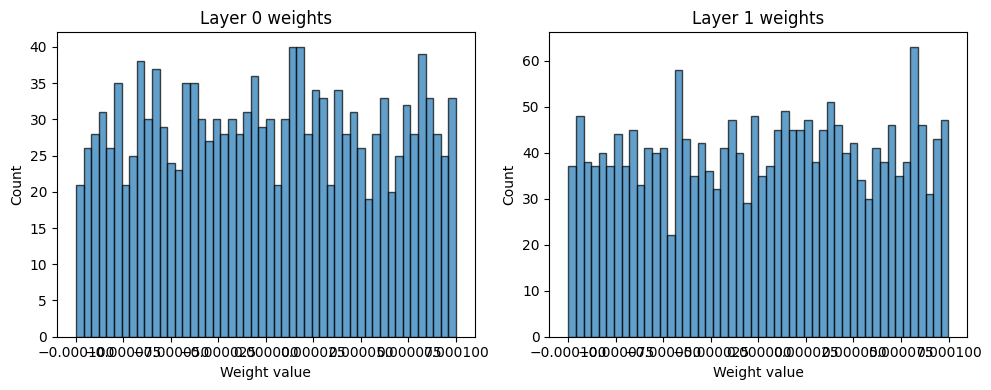

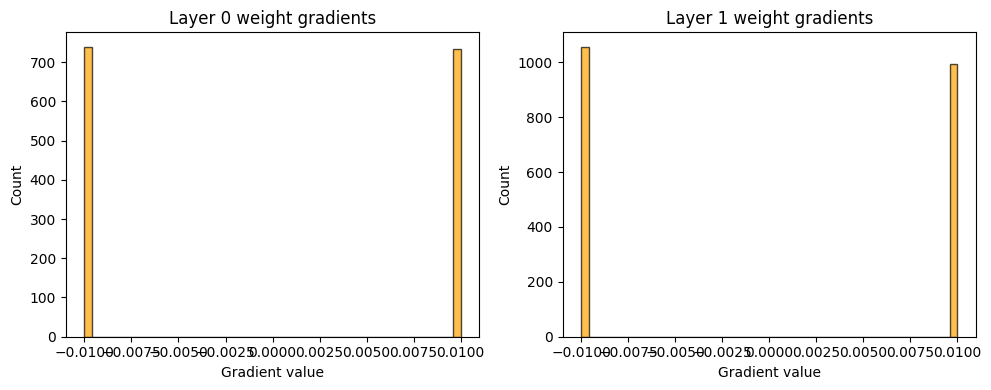


--- Training with Regularization: L2 ---


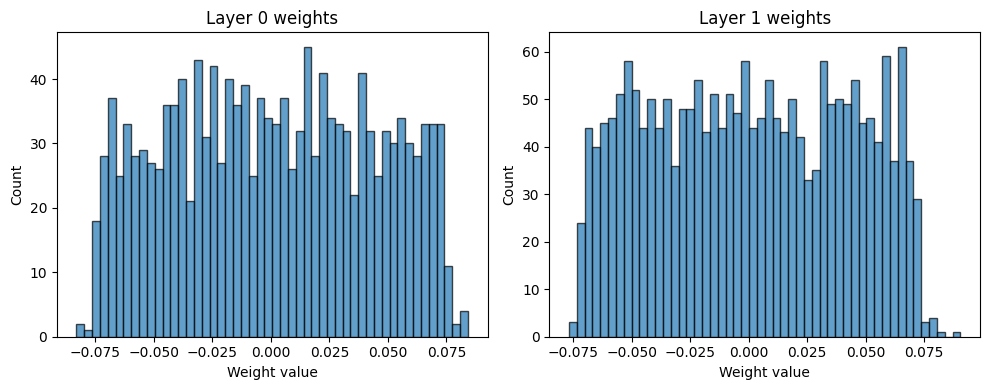

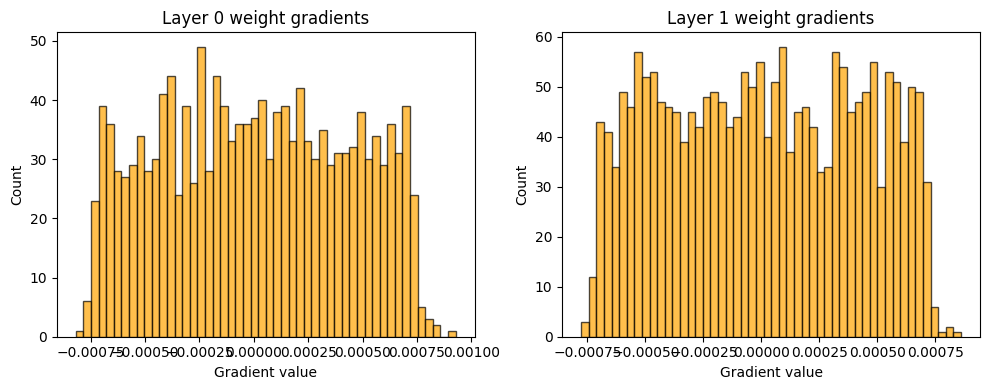

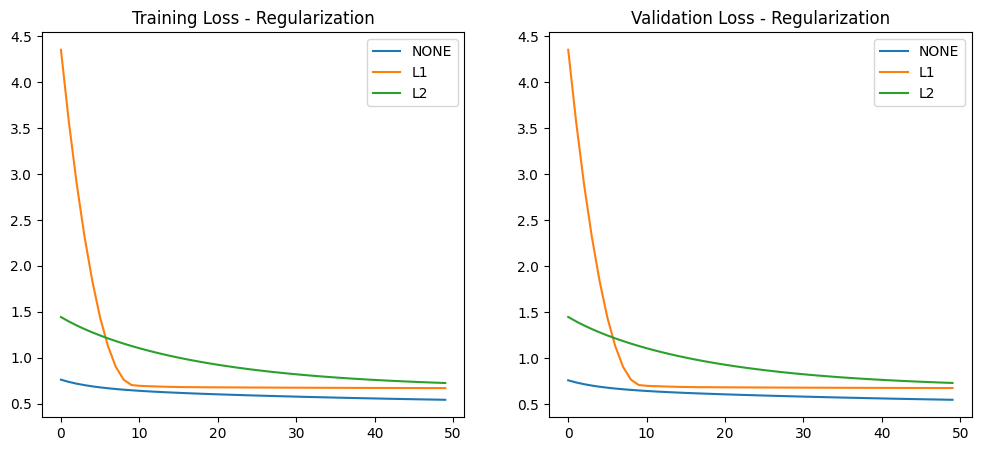

In [9]:
# --- EXPERIMENT: REGULARIZATION ---

reg_types = [None, "l1", "l2"]
reg_lambda = 0.01
histories_reg = {}
models_reg = {}

for reg in reg_types:
    reg_name = str(reg).upper() if reg else "NONE"
    print(f"\n--- Training with Regularization: {reg_name} ---")
    
    model = NeuralNetwork(
        layer_sizes=[input_dim, 64, 32, 1],
        activations=["relu", "relu", "sigmoid"],
        loss="bce",
        regularization=reg,
        reg_lambda=reg_lambda
    )
    
    history = model.fit(
        X_train=X_train, y_train=y_train, 
        val_data=(X_val, y_val),
        epochs=50, batch_size=32, learning_rate=0.01, verbose=0
    )
    
    histories_reg[reg_name] = history
    models_reg[reg_name] = model
    
    # Plot distributions [cite: 116]
    model.plot_weight_distribution(layers=[0, 1])
    model.plot_gradient_distribution(layers=[0, 1])

# Plotting Loss Comparisons
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for reg_name, hist in histories_reg.items():
    plt.plot(hist['train_loss'], label=reg_name)
plt.title('Training Loss - Regularization')
plt.legend()

plt.subplot(1, 2, 2)
for reg_name, hist in histories_reg.items():
    plt.plot(hist['val_loss'], label=reg_name)
plt.title('Validation Loss - Regularization')
plt.legend()
plt.show()

In [10]:
# --- EXPERIMENT: SKLEARN ---

print("\n--- Training Sklearn MLPClassifier ---")
# Using equivalent hyperparameters: 64 and 32 hidden neurons, relu, learning rate 0.01
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='sgd',
    batch_size=32,
    learning_rate_init=0.01,
    max_iter=50,
    random_state=42
)

# Sklearn expects 1D array for y
sklearn_mlp.fit(X_train, y_train.ravel())

# Predict and Compare [cite: 120]
y_pred_sklearn = sklearn_mlp.predict(X_val)
acc_sklearn = accuracy_score(y_val, y_pred_sklearn)

# Predict with our best from-scratch model (e.g., the L2 one)
our_preds_probs = models_reg["L2"].predict(X_val)
our_preds_classes = (our_preds_probs > 0.5).astype(int)
acc_ours = accuracy_score(y_val, our_preds_classes)

print(f"Sklearn MLP Accuracy: {acc_sklearn:.4f}")
print(f"Our FFNN (L2) Accuracy: {acc_ours:.4f}")


--- Training Sklearn MLPClassifier ---
Sklearn MLP Accuracy: 0.7270
Our FFNN (L2) Accuracy: 0.6125


d:\Kuliah\Sem_6\ML\ML-FFNN\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
